In [1]:
# Importing Libraries and RDKit modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset 
from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import Draw, AllChem, Descriptors, SanitizeMol
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.SaltRemover import SaltRemover

In [2]:
# Importing Scikit-Learn modules
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import recall_score, precision_score, confusion_matrix, roc_auc_score, f1_score, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.inspection import permutation_importance

### Loading The BBBP Dataset

In [3]:
df = pd.read_csv('BBBP.csv')
df.head()

,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


In [4]:
# Disabling RDKit warning and informational log messages
RDLogger.DisableLog('rdApp.*')

In [5]:
# Creating RDKit Molecule objects from the SMILES strings
df['Molecule'] = [Chem.MolFromSmiles(s) for s in df['smiles']]

# Counting invalid SMILES entries that could not be converted into Molecule objects
df['Molecule'].isna().sum()

np.int64(11)

In [6]:
# Removing the 'num' column and dropping rows with missing values
new_df = df.drop(columns='num').dropna(ignore_index=True)

In [7]:
# Initializing the SaltRemover object for salt stripping
remover = SaltRemover()

# Removing salts and retaining the main molecular structure for each compound
new_df['Molecule'] = new_df['Molecule'].apply(lambda mol: remover.StripMol(mol))

In [8]:
# Counting Molecule entries with missing or invalid values after salt removal
new_df['Molecule'].isna().sum()

np.int64(0)

In [9]:
# Calculating the number of molecular fragments for each compound and counting their frequency
new_df['Molecule'].apply(lambda mol: len(Chem.GetMolFrags(mol))).value_counts()

Molecule
1    1993
2      43
3       2
4       1
Name: count, dtype: int64

In [10]:
# Defining a function to retain the largest molecular fragment based on atom count
def keep_largest_fragment(mol):
    if mol is None:
        return None
    try:
        frags = Chem.GetMolFrags(mol, asMols=True)
        if len(frags) == 0:
            return mol
        return max(frags, key=lambda m: m.GetNumAtoms())
    except:
        return mol

In [11]:
# Applying the function keep largest fragment
new_df['Molecule'] = new_df['Molecule'].apply(keep_largest_fragment)

In [12]:
# Verifying the number of molecular fragments remaining for each compound after fragment selection
new_df['Molecule'].apply(lambda mol: len(Chem.GetMolFrags(mol))).value_counts()

Molecule
1    2039
Name: count, dtype: int64

In [13]:
# Defining a sanitization function to validate and clean RDKit molecules
def get_sanitization(mol):
    try:
         Chem.SanitizeMol(mol)
         return mol
    except:
         return None
    
# Applying sanitization and removing invalid molecular structures by setting them to None   
new_df['Molecule'] = new_df['Molecule'].apply(get_sanitization)

In [14]:
# Counting the number of molecules that became invalid (None) after sanitization
new_df['Molecule'].isna().sum()

np.int64(0)

In [15]:
# Initializing RDKit standardization tools for molecular preprocessing
normalizer = rdMolStandardize.Normalizer()
reionizer = rdMolStandardize.Reionizer()
uncharger = rdMolStandardize.Uncharger()
tautomer_enumerator = rdMolStandardize.TautomerEnumerator()

# Defining a function to standardize molecular structures
def get_standardization(mol):
    try:
        # Normalizing functional groups and molecular representations
        mol = normalizer.normalize(mol)
        # Standardizing ionization states
        mol = reionizer.reionize(mol)
        # Neutralizing formal charges where possible
        mol = uncharger.uncharge(mol)
        # Converting tautomers into a canonical tautomeric form
        mol = tautomer_enumerator.Canonicalize(mol)
        return mol
    except:
        return None

In [16]:
# Applying molecular standardization to all compounds in the dataset
new_df['Molecule'] = new_df['Molecule'].apply(get_standardization)

In [17]:
# Counting molecules that failed during the standardization process
new_df['Molecule'].isna().sum()

np.int64(0)

In [18]:
# Defining a function to check whether a molecule contains formally charged atoms
def get_charge(mol):
    return any(atom.GetFormalCharge() !=0 for atom in mol.GetAtoms())

# Counting molecules with and without formal charges
new_df['Molecule'].apply(get_charge).value_counts()

Molecule
False    1978
True       61
Name: count, dtype: int64

In [19]:
# Generating canonical SMILES representations for the standardized molecules
new_df['Canonical_Smiles'] = new_df['Molecule'].apply(Chem.MolToSmiles)

# Counting duplicate canonical SMILES entries in the dataset
new_df['Canonical_Smiles'].duplicated().sum()

np.int64(80)

### Duplicate Detection and Removal

An initial duplicate check was performed using canonical SMILES as the 
molecular identifier. Molecules sharing identical canonical SMILES were 
flagged as duplicates.

In [20]:
# Setting the maximum number of displayed rows in pandas output
pd.set_option('display.max_rows', 80)

In [21]:
# Identifying duplicated canonical SMILES entries and grouping their associated names and p_np values
new_df[new_df.duplicated(subset='Canonical_Smiles', keep=False)].groupby('Canonical_Smiles')[['name', 'p_np']].agg(list)

,name,p_np
Canonical_Smiles,,
C=COC=C,"[Divinylether, vinyl-ether]","[1, 1]"
CC(=O)NCCCOc1cccc(CN2CCCCC2)c1,"[24, 24]","[1, 1]"
CC(=O)Nc1ccc(O)cc1,"[acetaminophen, paracetamol(acetaminophen)]","[1, 1]"
CC(=O)Nc1nnc(S(N)(=O)=O)s1,"[acetozalamide, acetazolamide]","[1, 1]"
CC(=O)Oc1ccccc1C(=O)O,"[acetylsalicylate, aspirin]","[0, 1]"
CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,"[Terbutylchlorambucil, Tertbutylchlorambucil]","[1, 1]"
CC(C)NCC(O)COc1cccc2ccccc12,"[Propanolol, propranolol]","[1, 0]"
CC(C)c1cccc(C(C)C)c1O,"[propofol, propofol]","[1, 1]"
CC(C)c1nc(-c2ncn3c2CN(C)C(=O)c2c(Cl)cccc2-3)no1,"[33, L-663581]","[1, 1]"


### Conflicting Labels

Among the detected duplicates, several molecules were found to have 
conflicting p_np labels — the same molecular structure was assigned 
different BBB permeability values across different entries. These entries 
were examined before any removal decision was made.


In [22]:
# Identifying canonical SMILES entries associated with multiple distinct p_np values
conflicting = new_df.groupby('Canonical_Smiles')['p_np'].nunique()

# Extracting canonical SMILES with conflicting p_np annotations
conflicting_smiles = conflicting[conflicting > 1].index

# Displaying compound names and p_np values for conflicting canonical SMILES entries
new_df.loc[new_df['Canonical_Smiles'].isin(conflicting_smiles)].groupby('Canonical_Smiles')[['name', 'p_np']].agg(list)

,name,p_np
Canonical_Smiles,,
CC(=O)Oc1ccccc1C(=O)O,"[acetylsalicylate, aspirin]","[0, 1]"
CC(C)NCC(O)COc1cccc2ccccc12,"[Propanolol, propranolol]","[1, 0]"
CC1=C2CC(=O)C=C[C@]2(C)[C@@H]2[C@@H](C1)[C@@H]1CC[C@](O)(C(=O)CO)[C@@]1(C)C[C@@H]2O,"[Methylprednisolone, methylprednisolone]","[0, 1]"
CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1,"[loratadine, loratadine]","[0, 1]"
CN(C)C(=O)C(CCN1CCC(O)(c2ccc(Cl)cc2)CC1)(c1ccccc1)c1ccccc1,"[BRL53080, loperamide]","[1, 0]"
CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2,"[hyoscyamine, atropine, atropine(hyoscyamine)]","[1, 0, 1]"
COc1cc(NCc2ccc3nc(N)nc(N)c3c2C)cc(OC)c1OC,"[Trimetrexate, trimetrexate]","[0, 1]"
COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1,"[indomethacin, indomethacin(indometacin)]","[0, 1]"
Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)cc2Cl)c(Cl)c1,"[Miconazole, miconazole]","[0, 1]"


### Special Case: Aminophylline and Theophylline

A notable case was identified involving aminophylline and theophylline. 
Aminophylline is a mixture comprising theophylline and ethylenediamine 
in a 2:1 ratio. After salt removal and largest fragment selection, 
aminophylline was reduced to its theophylline component, resulting in 
identical canonical SMILES.

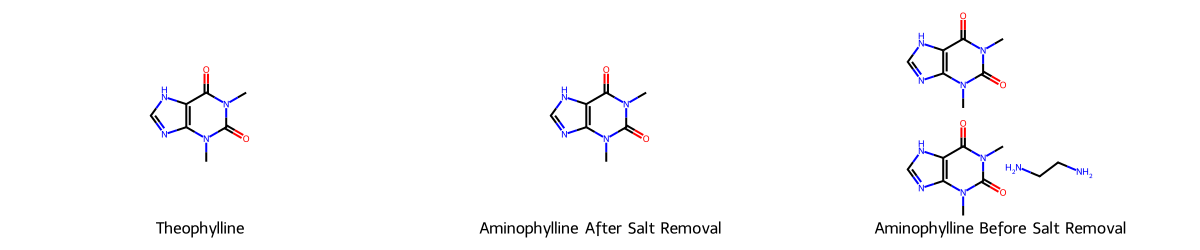

In [23]:
# Retrieving Molecule objects for theophylline and aminophylline after preprocessing
mols_list = new_df.loc[new_df['name'].isin(['theophylline', 'aminophylline'])]['Molecule'].to_list()

# Adding the original aminophylline structure before salt removal for comparison
mols_list.extend(df.loc[df['name'] == 'aminophylline']['Molecule'].to_list())

# Visualizing molecular structures before and after salt removal using a grid image
Draw.MolsToGridImage(mols_list, subImgSize = (400,250), legends = ['Theophylline', 'Aminophylline After Salt Removal', 'Aminophylline Before Salt Removal'])

The original SMILES from the dataset confirm this — aminophylline before 
salt removal clearly shows the presence of both components, while after 
processing it becomes structurally identical to theophylline.

Both entries will be removed from the dataset for two reasons:
- Conflicting p_np labels whose reliability cannot be verified
- Structural misrepresentation of aminophylline after preprocessing

### Dropping Duplicates with Conflicting p_np Labels

All molecules with conflicting p_np labels — including the aminophylline 
and theophylline case — were removed from the dataset, as their labels 
cannot be considered reliable.

In [24]:
# Removing compounds with conflicting p_np annotations and resetting the DataFrame index
new_df = new_df[~new_df['Canonical_Smiles'].isin(conflicting_smiles)].reset_index(drop=True)

### Checking again the remaining Duplicates

In [25]:
# Checking for any remaining duplicate canonical SMILES entries after removing conflicting cases
new_df[new_df.duplicated(subset='Canonical_Smiles', keep=False)].groupby('Canonical_Smiles')[['name', 'p_np']].agg(list)

,name,p_np
Canonical_Smiles,,
C=COC=C,"[Divinylether, vinyl-ether]","[1, 1]"
CC(=O)NCCCOc1cccc(CN2CCCCC2)c1,"[24, 24]","[1, 1]"
CC(=O)Nc1ccc(O)cc1,"[acetaminophen, paracetamol(acetaminophen)]","[1, 1]"
CC(=O)Nc1nnc(S(N)(=O)=O)s1,"[acetozalamide, acetazolamide]","[1, 1]"
CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,"[Terbutylchlorambucil, Tertbutylchlorambucil]","[1, 1]"
CC(C)c1cccc(C(C)C)c1O,"[propofol, propofol]","[1, 1]"
CC(C)c1nc(-c2ncn3c2CN(C)C(=O)c2c(Cl)cccc2-3)no1,"[33, L-663581]","[1, 1]"
CC(CN1c2ccccc2Sc2ccccc21)N(C)C,"[promethazine-HCl, promethazine]","[1, 1]"
CC1(C)S[C@@H]2C(NC(=O)C(N)c3ccccc3)C(=O)N2C1C(=O)O,"[ampicillin, sultamicillin]","[0, 0]"


### Further Duplicate Examination

After removing conflicting labels, the remaining duplicates were examined 
individually. Several cases were identified that required special attention 
beyond simple duplicate removal, including incorrect SMILES entries and 
molecules whose structure was altered during preprocessing.

### Case 1: Sultamicillin and Ampicillin

During duplicate examination, sultamicillin and ampicillin were found to 
share identical canonical SMILES. The structures were visualized to 
investigate this finding.

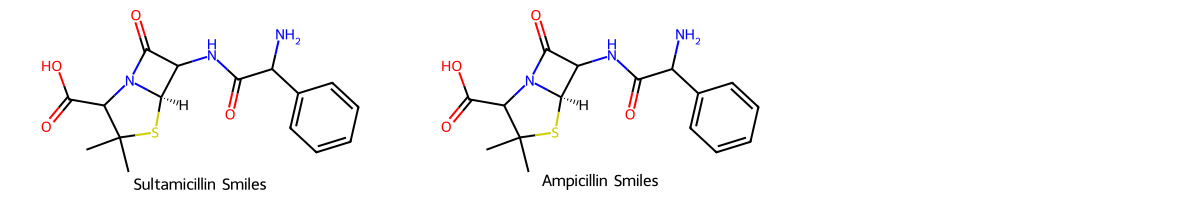

In [26]:
# Extracting molecular structures for sultamicillin and ampicillin for visual comparison
mols_list_2 = new_df.loc[new_df['name'].isin(['sultamicillin', 'ampicillin'])]['Molecule'].to_list()

# Visualizing both molecules in a grid layout with labels
Draw.MolsToGridImage(mols_list_2, subImgSize = (400,200), legends = ['Sultamicillin Smiles', 'Ampicillin Smiles'])

After preprocessing, sultamicillin and ampicillin were found to share 
identical canonical SMILES, resulting in the same molecular structure. 
To investigate this, we first examine the original SMILES of sultamicillin 
from the dataset prior to salt removal.

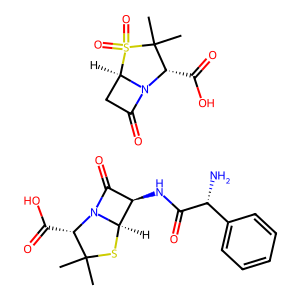

In [27]:
# Extracting the original (preprocessing) molecular structure of sultamicillin
original_sultamicillin = df.loc[df['name'] == 'sultamicillin']['Molecule'].iloc[0]

# Visualizing the structure of the original molecule
Draw.MolToImage(original_sultamicillin)

Visualization of sultamicillin's original SMILES from the dataset revealed 
an incorrect representation — the molecule was encoded as two separate 
fragments using a '.' separator, which caused the largest fragment 
selection step to retain only the ampicillin component, discarding the 
sulbactam portion entirely.

### Sultamicillin: Correct Structure (PubChem)

The correct structure of sultamicillin retrieved from PubChem confirms 
that it is a single unified molecule — ampicillin and sulbactam connected 
via a covalent bond.

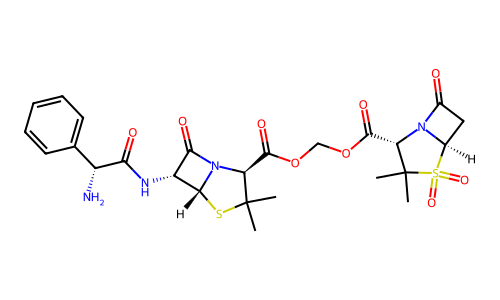

In [28]:
# Visualizing the molecular structure from a SMILES string representation
Draw.MolToImage(Chem.MolFromSmiles('CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H](C3=CC=CC=C3)N)C(=O)OCOC(=O)[C@H]4C(S(=O)(=O)[C@H]5N4C(=O)C5)(C)C)C'), size = (500,300))

Based on the above examination, the sultamicillin entry will be removed 
from the dataset. The incorrect SMILES representation led to a corrupted 
structure after preprocessing, making this entry unreliable for model training.

### Case 2: Bacitracin and Acebutolol

During duplicate examination, it was found that they were two bacitracin entries and one of them
shared identical canonical SMILES with acebutolol. To investigate this, 
we examine both bacitracin entries from the dataset.

In [29]:
# Filtering the dataset to inspect specific compounds: Bacitracin and Acebutolol
new_df.loc[new_df['name'].isin(['Bacitracin', 'Acebutolol'])]

,name,p_np,smiles,Molecule,Canonical_Smiles
51,Bacitracin,1,c1(c(cc(NC(CCC)=O)cc1)C(C)=O)OCC(CNC(C)C)O,<rdkit.Chem.rdchem.Mol object at 0x000001B8F0E...,CCCC(=O)Nc1ccc(OCC(O)CNC(C)C)c(C(C)=O)c1
191,Bacitracin,0,CCC(C)C(N)C1=NC(CS1)C(=O)N[C@@H](CC(C)C)C(=O)N...,<rdkit.Chem.rdchem.Mol object at 0x000001B8F0E...,CCC(C)C(N)C1=NC(C(=O)NC(CC(C)C)C(=O)NC(CCC(=O)...
660,Acebutolol,1,CCCC(=O)Nc1ccc(OCC(O)CNC(C)C)c(c1)C(C)=O,<rdkit.Chem.rdchem.Mol object at 0x000001B8F0E...,CCCC(=O)Nc1ccc(OCC(O)CNC(C)C)c(C(C)=O)c1


The original dataset contains two bacitracin entries with different SMILES. 
We visualize all three molecules to identify which entry is incorrect.

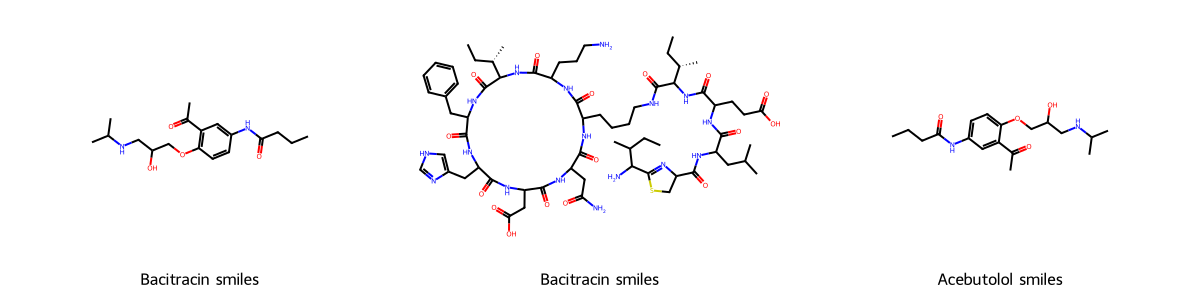

In [30]:
# Visualizing selected molecular structures using a grid layout for comparison
Draw.MolsToGridImage(new_df.loc[[51,191,660], 'Molecule'], subImgSize = (400,300), legends = ['Bacitracin smiles', 'Bacitracin smiles','Acebutolol smiles'])

The visualization confirms that one bacitracin entry contains an incorrect 
SMILES — identical to acebutolol. This is clearly a data entry error in 
the dataset. The incorrect entry will be removed while the correct 
bacitracin entry will be retained.

### Case 3: Bretyliumtosilate and Albendazole

During duplicate examination, it was found that there were two Bretylium 
Tosylate entries and one of them shared identical canonical SMILES with 
Albendazole. We first examine all three entries in the current dataset.

In [31]:
# Inspecting specific compounds: Bretylium tosylate and Albendazole
new_df.loc[new_df['name'].isin(['Bretyliumtosilate','Albendazole' ])]

,name,p_np,smiles,Molecule,Canonical_Smiles
75,Bretyliumtosilate,1,c12c(nc([nH]1)NC(OC)=O)cc(SCCC)cc2,<rdkit.Chem.rdchem.Mol object at 0x000001B8F0E...,CCCSc1ccc2[nH]c(NC(=O)OC)nc2c1
193,Bretyliumtosilate,0,CC[N+](C)(C)Cc1ccccc1Br.Cc2ccc(cc2)[S]([O-])(=...,<rdkit.Chem.rdchem.Mol object at 0x000001B8F0E...,CC[N+](C)(C)Cc1ccccc1Br
662,Albendazole,1,CCCSc1ccc2nc(NC(=O)OC)[nH]c2c1,<rdkit.Chem.rdchem.Mol object at 0x000001B8F0E...,CCCSc1ccc2[nH]c(NC(=O)OC)nc2c1


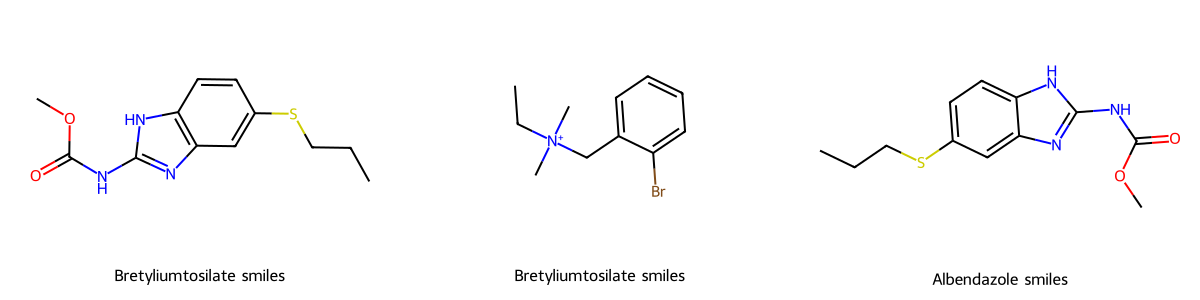

In [32]:
# Visualizing selected molecular structures for comparison in a grid layout
Draw.MolsToGridImage(new_df.loc[[75,193,662], 'Molecule'], subImgSize = (400,300), legends = ['Bretyliumtosilate smiles', 'Bretyliumtosilate smiles','Albendazole smiles'])

The visualization of the three entries confirms that one Bretylium Tosylate 
entry shares the same structure as Albendazole — a clear data entry error.
The second Bretylium Tosylate entry appears to have been altered during 
salt removal, retaining only one fragment of the original molecule. 
We examine the original dataset to confirm this.

In [33]:
# Inspecting the original dataset entry for Bretylium tosylate
df.loc[df['name'] == 'Bretyliumtosilate']

,num,name,p_np,smiles,Molecule
80,82,Bretyliumtosilate,1,c12c(nc([nH]1)NC(OC)=O)cc(SCCC)cc2,<rdkit.Chem.rdchem.Mol object at 0x000001B8EEE...
202,204,Bretyliumtosilate,0,CC[N+](C)(C)Cc1ccccc1Br.Cc2ccc(cc2)[S]([O-])(=...,<rdkit.Chem.rdchem.Mol object at 0x000001B8EEE...


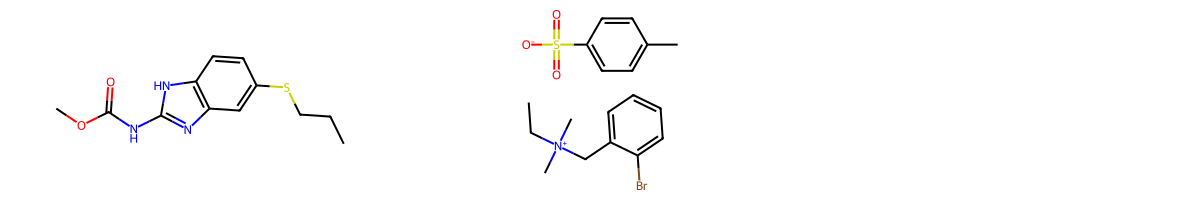

In [34]:
# Visualizing selected molecular structures from the original dataset
Draw.MolsToGridImage(df.loc[[80,202], 'Molecule'], subImgSize = (400,200))

The original dataset confirms that the second Bretylium Tosylate entry 
contained two fragments — after salt removal only the largest fragment 
was retained, resulting in an unreliable molecular representation.
Both entries will therefore be removed from the dataset.

### Case 4: Lymecycline and Chlortetracycline

During duplicate examination, lymecycline and chlortetracycline were found 
to share identical canonical SMILES. The structures were visualized to 
investigate this finding.

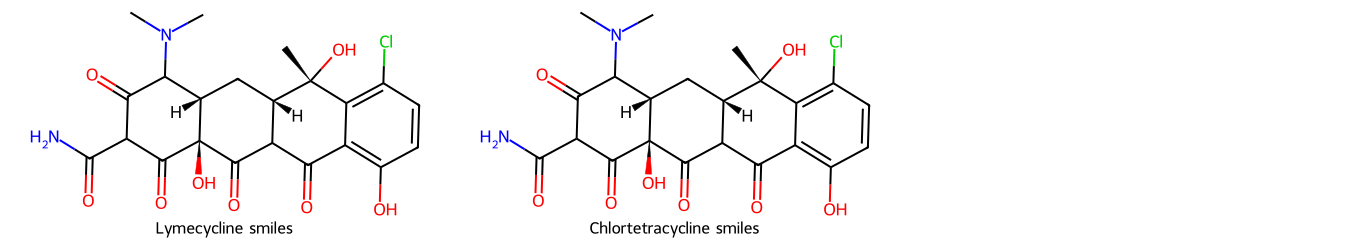

In [35]:
# Extracting molecular structures for lymecycline and chlortetracycline for visual comparison
mols_list_3 = new_df.loc[new_df['name'].isin(['lymecycline','Chlortetracycline' ])]['Molecule'].to_list()

# Visualizing both molecules in a grid layout with labels
Draw.MolsToGridImage(mols_list_3, subImgSize = (450,250), legends = ['Lymecycline smiles', 'Chlortetracycline smiles'])

Both entries display the structure of chlortetracycline, confirming that 
the lymecycline entry contains an incorrect SMILES in the dataset. 
Verification via PubChem confirms that these are distinct compounds. 
The correct structure of lymecycline is shown below.

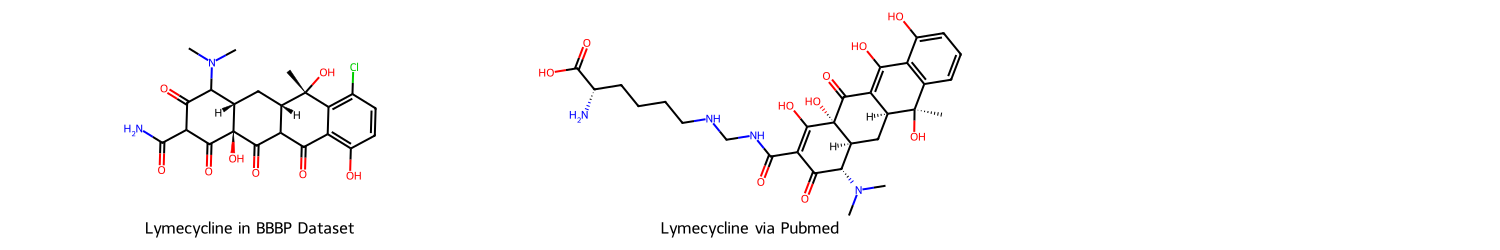

In [36]:
# Creating a reference Lymecycline structure from a PubMed SMILES string
lymecycline_pubmed = Chem.MolFromSmiles('C[C@@]1([C@H]2C[C@H]3[C@@H](C(=O)C(=C([C@]3(C(=O)C2=C(C4=C1C=CC=C4O)O)O)O)C(=O)NCNCCCC[C@@H](C(=O)O)N)N(C)C)O')

# Extracting Lymecycline from the BBBP dataset
lymecycline_BBBP = new_df.loc[new_df['name'] ==  'lymecycline']['Molecule'].iloc[0]

# Visual comparison between dataset structure and PubMed reference
Draw.MolsToGridImage([lymecycline_BBBP, lymecycline_pubmed], subImgSize = (500, 250), legends = ['Lymecycline in BBBP Dataset', 'Lymecycline via Pubmed'])

The lymecycline entry will be removed from the dataset due to incorrect 
SMILES representation. As the molecular structure is wrong, the p_np 
label cannot be considered reliable either.

### Dropping the remaining duplicates

In [37]:
# Collecting indices of molecules suspected to have incorrect SMILES representations
wrong_smiles = new_df[new_df['name'].isin(['lymecycline', 'sultamicillin', 'Bretyliumtosilate'])].index.tolist()

# Adding a manually identified incorrect Bacitracin entry
false_bacitracin = 51
wrong_smiles.append(false_bacitracin)

In [38]:
# Removing entries with identified incorrect SMILES and resetting the DataFrame index
new_df = new_df.drop(index = wrong_smiles).reset_index(drop = True)

In [39]:
# Removing duplicate compounds based on Canonical SMILES and keeping only the first occurrence
new_df = new_df.drop_duplicates(subset='Canonical_Smiles', keep='first').reset_index(drop = True)

In [40]:
# Displaying the distribution of the target variable (p_np) in counts and proportions
print(new_df['p_np'].value_counts())
print(new_df['p_np'].value_counts(normalize=True))

p_np
1    1490
0     456
Name: count, dtype: int64
p_np
1    0.765673
0    0.234327
Name: proportion, dtype: float64


In [41]:
# Calculating key molecular descriptors for each compound:
# Molecular weight, topological polar surface area, lipophilicity (LogP), number of hydrogen bond donors and number of rotatable bonds

new_df['Molecular_Weight'] = new_df['Molecule'].apply(Descriptors.MolWt)
new_df['TPSA'] = new_df['Molecule'].apply(Descriptors.TPSA)
new_df['LogP'] = new_df['Molecule'].apply(Descriptors.MolLogP)
new_df['H_Donors'] = new_df['Molecule'].apply(Descriptors.NumHDonors)
new_df['Rotatable_Bonds'] = new_df['Molecule'].apply(Descriptors.NumRotatableBonds)

In [42]:
# Initializing Morgan fingerprint generator (ECFP-like fingerprints) with radius 2 and size 2048 bits
fps_gen = AllChem.GetMorganGenerator(radius =2 , fpSize = 2048)

# Generating fingerprints for each molecule and converting them into NumPy arrays
fps = [fps_gen.GetFingerprintAsNumPy(mol) for mol in new_df['Molecule']]

# Creating a DataFrame where each column corresponds to a fingerprint bit
df_fps = pd.DataFrame(fps, columns = [f'fp{x}' for x  in range(2048)])

# Displaying the first rows of the fingerprint feature matrix
df_fps.head()

,fp0,fp1,fp2,fp3,fp4,fp5,fp6,fp7,fp8,fp9,...,fp2038,fp2039,fp2040,fp2041,fp2042,fp2043,fp2044,fp2045,fp2046,fp2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [43]:
# Combining the original dataset with the generated fingerprint features
complete_df = pd.concat([new_df, df_fps], axis = 1)

# Displaying the first rows of the final combined dataset
complete_df.head()

,name,p_np,smiles,Molecule,Canonical_Smiles,Molecular_Weight,TPSA,LogP,H_Donors,Rotatable_Bonds,...,fp2038,fp2039,fp2040,fp2041,fp2042,fp2043,fp2044,fp2045,fp2046,fp2047
0,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,<rdkit.Chem.rdchem.Mol object at 0x000001B8F0E...,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,360.325,29.54,4.63500,0,9,...,0,0,0,0,0,0,0,0,0,0
1,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...,<rdkit.Chem.rdchem.Mol object at 0x000001B8F0E...,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,361.373,75.01,1.54400,1,2,...,0,0,0,0,0,0,0,1,0,0
2,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C,<rdkit.Chem.rdchem.Mol object at 0x000001B8F0E...,CC(=O)NCCCOc1cccc(CN2CCCCC2)c1,290.407,41.57,2.57750,1,7,...,0,0,0,0,0,0,0,0,0,0
3,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,<rdkit.Chem.rdchem.Mol object at 0x000001B8F0E...,Cc1onc(-c2ccccc2Cl)c1C(=O)NC1C(=O)N2C(C(=O)O)C...,435.889,112.74,2.54872,2,4,...,1,0,0,0,0,0,0,0,0,0
4,cefoperazone,1,CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(...,<rdkit.Chem.rdchem.Mol object at 0x000001B8F0E...,CCN1CCN(C(=O)NC(C(=O)NC2C(=O)N3C(C(=O)O)=C(CSc...,645.680,220.26,-1.11200,4,9,...,0,0,0,1,0,0,0,0,0,0


## Scaffold-Based Train/Test Split 

In [44]:
# Generating Murcko scaffold for each molecule
new_df['Scaffold'] = new_df['Molecule'].apply(lambda mol: MurckoScaffold.MurckoScaffoldSmiles(mol = mol))

# Grouping molecules by scaffold
scaffolds = new_df.groupby('Scaffold').indices

# Sorting scaffolds by size (largest first)
sorted_scaffolds = sorted(scaffolds.items(), key = lambda x: len(x[1]), reverse = True)

# Initializing split containers
train_idx = []
test_idx = []

# Defining target training set size (80% of dataset)
train_size = int(0.8 * len(new_df))

# Assigning scaffolds to train/test sets while preserving scaffold integrity
for scaffold, indices in sorted_scaffolds:
    if len(train_idx) + len(indices) <= train_size:
        train_idx.extend(indices)
    else:
        test_idx.extend(indices)

# Creating final datasets
train_df = new_df.loc[train_idx]
test_df = new_df.loc[test_idx]

In [45]:
# Computing the mean of the target variable (p_np) in the training set
train_df['p_np'].mean()

np.float64(0.7455012853470437)

In [46]:
# Computing the mean of the target variable (p_np) in the test set
test_df['p_np'].mean()

np.float64(0.8461538461538461)

### Setting the Predictors and the Target

In [47]:
# Creating a list of molecular descriptors present in the dataset
numeric_columns = ['Molecular_Weight', 'TPSA', 'LogP', 'H_Donors', 'Rotatable_Bonds']

# Constructing training feature matrix by combining descriptors with Morgan fingerprints
X_train = pd.concat([train_df.loc[:, numeric_columns], df_fps.loc[train_df.index]], axis = 1)

# Defining training labels
y_train = train_df['p_np']

# Constructing test feature matrix in the same way
X_test = pd.concat([test_df.loc[:, numeric_columns], df_fps.loc[test_df.index]], axis = 1)

# Defining test labels
y_test= test_df['p_np']

In [48]:
# Applying Standard Scaler to numeric columns and pass fingerprints features unchanged
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numeric_columns),
                                               ('fp', 'passthrough', df_fps.columns)])

# Model Training and Evaluation

## Logistic Regression

In [49]:
# Defining a logistic regression model within a preprocessing pipeline
logistic_regression_model = make_pipeline(preprocessor, LogisticRegression(max_iter=300))

# Defining the hyperparameter grid for GridSearchCV
param_grid_logistic_regression =[ 
    {
    'logisticregression__C' : [0.001, 0.01, 0.05, 0.1, 1, 10],
    'logisticregression__solver' : ['saga'],
    'logisticregression__penalty' : ['l1', 'l2'],
    'logisticregression__class_weight' : [None, 'balanced'],
    },
    {
    'logisticregression__C' : [0.001, 0.01, 0.05, 0.1, 1, 10],
    'logisticregression__solver' : ['saga'],
    'logisticregression__penalty' : ['elasticnet'],
    'logisticregression__class_weight' : [None, 'balanced'],
    'logisticregression__l1_ratio' : [0.3, 0.5, 0.7, 0.9]
    }
]

In [50]:
# Performing hyperparameter tuning for the logistic regression model pipeline using GridSearchCV
logistic_regression_cv = GridSearchCV(estimator = logistic_regression_model, param_grid = param_grid_logistic_regression , cv = 5, n_jobs = -1, scoring = 'roc_auc')

In [51]:
# Training the logistic regression model
logistic_regression_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Molecular_Weight',
                                                                          'TPSA',
                                                                          'LogP',
                                                                          'H_Donors',
                                                                          'Rotatable_Bonds']),
                                                                        ('fp',
                                                                         'passthrough',
                                                                         Index(['fp0', 'fp1', 'fp2', 'fp3', 'fp4', 'fp5', 'fp6', 'fp7', 'fp8', 'fp9',
       ...
       'fp2038', 'fp2039', 'fp2040', 'fp2041', 'fp2042', 'fp2043', 'fp2044',
       'fp2045', 'f...
                                                               'balanced'],
                          'logisticregression__penalty': ['l1', 'l2'],
                          'logisticregression__solver': ['saga']},
                         {'logisticregression__C': [0.001, 0.01, 0.05, 0.1, 1,
                                                    10],
                          'logisticregression__class_weight': [None,
                                                               'balanced'],
                          'logisticregression__l1_ratio': [0.3, 0.5, 0.7, 0.9],
                          'logisticregression__penalty': ['elasticnet'],
                          'logisticregression__solver': ['saga']}],
             scoring='roc_auc')

In [52]:
# Retrieving the best hyperparameters found during GridSearchCV optimization
logistic_regression_cv.best_params_

{'logisticregression__C': 0.1,
 'logisticregression__class_weight': 'balanced',
 'logisticregression__l1_ratio': 0.3,
 'logisticregression__penalty': 'elasticnet',
 'logisticregression__solver': 'saga'}

In [53]:
# Retrieving the best cross-validated ROC-AUC score from GridSearchCV
logistic_regression_cv.best_score_

np.float64(0.9043072075512878)

In [54]:
# Extracting the best logistic regression model from the fitted GridSearchCV pipeline
best_estimator_log_reg = logistic_regression_cv.best_estimator_

# Accessing the logistic regression step inside the pipeline
best_logistic_regression = best_estimator_log_reg.named_steps['logisticregression']

# Counting how many coefficients are non-zero
num_nonzero = np.sum(best_logistic_regression.coef_ != 0)

# Printing the number of non-zero model coefficients
print(num_nonzero)

221


In [55]:
# Generating class predictions on the test set using the best logistic regression model
y_pred_logistic_regression = best_estimator_log_reg.predict(X_test)

# Extracting predicted probabilities for the positive class (class 1)
y_proba_logistic_regression = best_estimator_log_reg.predict_proba(X_test)[:, 1]

In [56]:
# Computing ROC-AUC score for the logistic regression model on the test set
roc_auc_log_reg = roc_auc_score(y_test, y_proba_logistic_regression)

# Displaying the model performance metric
print(f'The roc auc score for the logistic regression model is {roc_auc_log_reg}')

The roc auc score for the logistic regression model is 0.7602020202020202


In [57]:
# Printing detailed classification metrics for the logistic regression model
print(classification_report(y_test, y_pred_logistic_regression))

              precision    recall  f1-score   support

           0       0.48      0.40      0.44        60
           1       0.89      0.92      0.91       330

    accuracy                           0.84       390
   macro avg       0.69      0.66      0.67       390
weighted avg       0.83      0.84      0.83       390



In [58]:
# Computing the confusion matrix for the final logistic regression model
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_logistic_regression)

# Displaying the confusion matrix
print(f'The confusion matrix for the final logistic regression model is:\n{conf_matrix_log_reg}')

The confusion matrix for the final logistic regression model is:
[[ 24  36]
 [ 26 304]]


In [59]:
# Computing the PR-AUC (Average Precision) score for the final logistic regression model
ap_log_reg = average_precision_score(y_test, y_proba_logistic_regression)

# Displaying the PR-AUC score
print(f'The PR-AUC score for the final logistic regression model is {ap_log_reg}')

The PR-AUC score for the final logistic regression model is 0.9421461032907495


In [60]:
# Computing additional evaluation metrics for the final logistic regression model
precision_log_reg = precision_score(y_test, y_pred_logistic_regression)
recall_log_reg = recall_score(y_test, y_pred_logistic_regression)
f1_score_log_reg = f1_score(y_test, y_pred_logistic_regression)

# Displaying precision, recall, and F1-score
print(f'The precision for the logistic regression model is {precision_log_reg}')
print(f'The recall for the logistic regression model is {recall_log_reg}')
print(f'The f1 score for the logistic regression model is {f1_score_log_reg}')

The precision for the logistic regression model is 0.8941176470588236
The recall for the logistic regression model is 0.9212121212121213
The f1 score for the logistic regression model is 0.9074626865671642


#### Logistic Regression – Initial Hyperparameter Optimization

A Logistic Regression model was trained within a preprocessing pipeline combining standardized molecular descriptors and Morgan fingerprint features. Hyperparameter optimization was performed using `GridSearchCV` with five-fold cross-validation and ROC-AUC as the evaluation metric.

The search explored different regularization strategies (`L1`, `L2`, and `Elastic Net`), multiple regularization strengths (`C` values), and optional class balancing in order to identify the most robust configuration for BBB permeability prediction.

The optimal configuration selected:

- Elastic Net regularization
- `C = 0.1`
- `l1_ratio = 0.3`
- `class_weight = 'balanced'`

This configuration achieved a test ROC-AUC score of approximately **0.76**.

The selected model retained 220 non-zero coefficients, indicating that predictive performance was driven by a relatively broad subset of molecular fingerprint and descriptor features rather than an extremely sparse representation. This behavior is consistent with the moderate Elastic Net regularization selected during optimization, which balances feature selection (`L1`) and coefficient stabilization (`L2`).

The use of `class_weight='balanced'` suggests that compensating for class imbalance improved the model’s ability to distinguish BBB-permeable and non-permeable compounds under scaffold-split evaluation conditions.

Overall, the resulting Logistic Regression model demonstrated stable and interpretable predictive behavior while maintaining competitive discriminative performance on the scaffold-based test set.

## Support Vector Classifier

In [61]:
# Defining an SVC classifier with RBF kernel inside a preprocessing pipeline
svc_model = make_pipeline(preprocessor, SVC(kernel='rbf', probability=True, random_state=42))

# Defining the hyperparameter search space for SVC optimization
param_grid_svc = {
    'svc__C': [0.1, 1, 10, 100, 1000],
    'svc__gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'svc__class_weight': [None, 'balanced']
}

In [62]:
# Setting up RandomizedSearchCV for SVC hyperparameter optimization
svc_cv = RandomizedSearchCV(estimator=svc_model, param_distributions=param_grid_svc, n_iter=20,  cv=5, n_jobs=-1, scoring='roc_auc', random_state=42)

In [63]:
# Training the SVC model 
svc_cv.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Molecular_Weight',
                                                                                'TPSA',
                                                                                'LogP',
                                                                                'H_Donors',
                                                                                'Rotatable_Bonds']),
                                                                              ('fp',
                                                                               'passthrough',
                                                                               Index(['fp0', 'fp1', 'fp2', 'fp3', 'fp4', 'fp5', 'fp6', 'fp7', 'fp8', 'fp9',
       ...
       'fp2038', 'fp2039', 'fp2040', 'fp2041', 'fp2042', 'fp2043', 'fp2044',
       'fp2045', 'fp2046', 'fp2047'],
      dtype='object', length=2048))])),
                                             ('svc',
                                              SVC(probability=True,
                                                  random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'svc__C': [0.1, 1, 10, 100, 1000],
                                        'svc__class_weight': [None, 'balanced'],
                                        'svc__gamma': ['scale', 0.001, 0.01,
                                                       0.1, 1]},
                   random_state=42, scoring='roc_auc')

In [64]:
# Retrieving the best hyperparameters found for the SVC model
svc_cv.best_params_

{'svc__gamma': 'scale', 'svc__class_weight': 'balanced', 'svc__C': 1}

In [65]:
# Retrieving the best cross-validated ROC-AUC score for the SVC model
svc_cv.best_score_

np.float64(0.908923505019642)

In [66]:
# Extracting the best-performing SVC pipeline from RandomizedSearchCV
best_estimator_svc = svc_cv.best_estimator_

In [67]:
# Generating predictions and positive class probabilities for the SVC model
y_pred_svc = best_estimator_svc.predict(X_test)
y_proba_svc = best_estimator_svc.predict_proba(X_test)[:, 1]

In [68]:
# Computing evaluation metrics for the SVC model
roc_auc_score_svc = roc_auc_score(y_test, y_proba_svc)
ap_svc = average_precision_score(y_test, y_proba_svc)

# Displaying ROC-AUC and PR-AUC scores
print(f'The roc auc score for the svc model is {roc_auc_score_svc}')
print(f'The PR-AUC score for the svc model is {ap_svc}')

The roc auc score for the svc model is 0.812020202020202
The PR-AUC score for the svc model is 0.9579940638293559


In [69]:
# Computing the confusion matrix for the SVC model
conf_matrix_svc = confusion_matrix(y_test, y_pred_svc)

# Displaying the confusion matrix
print(f'The confusion matrix for the svc model is:\n{conf_matrix_svc}')

The confusion matrix for the svc model is:
[[ 22  38]
 [ 14 316]]


In [70]:
# Computing classification metrics for the SVC model
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_score_svc = f1_score(y_test, y_pred_svc)

# Displaying precision, recall, and F1-score
print(f'The precision for svc model is {precision_svc}')
print(f'The recall for the svc model is {recall_svc}')
print(f'The f1 score for the svc model is {f1_score_svc}')

The precision for svc model is 0.8926553672316384
The recall for the svc model is 0.9575757575757575
The f1 score for the svc model is 0.9239766081871345


In [71]:
# Printing detailed classification metrics for the SVC model
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.61      0.37      0.46        60
           1       0.89      0.96      0.92       330

    accuracy                           0.87       390
   macro avg       0.75      0.66      0.69       390
weighted avg       0.85      0.87      0.85       390



#### Support Vector Classifier – Hyperparameter Optimization and Performance Evaluation

A Support Vector Classifier (SVC) with an RBF kernel was trained within the preprocessing pipeline using standardized molecular descriptors and Morgan fingerprint features. Hyperparameter optimization was performed using `RandomizedSearchCV` with five-fold cross-validation and ROC-AUC as the evaluation metric.

The search explored different values of the regularization parameter (`C`), kernel coefficient (`gamma`), and optional class balancing in order to identify the most effective decision boundary for BBB permeability prediction.

The optimal configuration selected:

- `C = 1`
- `gamma = 'scale'`
- `class_weight = 'balanced'`

The optimized SVC model achieved a test ROC-AUC score of approximately **0.81**, representing a strong improvement in discriminative performance under scaffold-based evaluation conditions.

Additional evaluation metrics demonstrated strong overall classification performance:

- Precision: **0.893**
- Recall: **0.958**
- F1-score: **0.924**
- PR-AUC: **0.958**

The confusion matrix further showed that the model successfully identified the majority of BBB-permeable compounds while maintaining a more balanced classification behavior for the negative class.

Overall, the Support Vector Classifier demonstrated strong predictive performance and effective handling of the high-dimensional molecular fingerprint representation, making it a highly competitive candidate for final model selection.

# Random Forest Classifier

In [72]:
# Initializing a Random Forest classifier
rfc_model = RandomForestClassifier()

# Defining the hyperparameter search space for Random Forest tuning
param_grid_rfc = {
    'n_estimators' : [200, 300, 500],
    'max_depth' : [None, 10, 20, 30, 40, 50],
    'min_samples_leaf' : [1, 2, 4, 6],
    'min_samples_split' : [2, 5, 10],
    'max_features' : ['sqrt', 'log2', 0.3, 0.5],
    'class_weight' : [None, 'balanced']
}

In [73]:
# Setting up RandomizedSearchCV for Random Forest hyperparameter optimization
rfc_cv = RandomizedSearchCV(estimator=rfc_model, param_distributions=param_grid_rfc, n_iter=100, cv=5, n_jobs=-1, scoring='roc_auc', random_state=42)

In [74]:
# Training the Random Forest model
rfc_cv.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': [None, 10, 20, 30, 40, 50],
                                        'max_features': ['sqrt', 'log2', 0.3,
                                                         0.5],
                                        'min_samples_leaf': [1, 2, 4, 6],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 500]},
                   random_state=42, scoring='roc_auc')

In [75]:
# Retrieving the best hyperparameters found for the Random Forest model
rfc_cv.best_params_

{'n_estimators': 500,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 50,
 'class_weight': 'balanced'}

In [76]:
# Retrieving the best cross-validated ROC-AUC score for the Random Forest model
rfc_cv.best_score_

np.float64(0.9134173123090352)

In [77]:
# Extracting the best-performing Random Forest model from RandomizedSearchCV
best_estimator_rfc = rfc_cv.best_estimator_

In [78]:
# Generating predictions and positive class probabilities using the Random Forest model
y_pred_rfc = best_estimator_rfc.predict(X_test)
y_proba_rfc = best_estimator_rfc.predict_proba(X_test)[:,1]

In [79]:
# Computing evaluation metrics for the Random Forest model
roc_auc_score_rfc = roc_auc_score(y_test, y_proba_rfc)
ap_rfc = average_precision_score(y_test, y_proba_rfc)

# Displaying ROC-AUC and PR-AUC scores
print(f'The roc auc score for the random forest classifier model is {roc_auc_score_rfc}')
print(f'The PR-AUC score for the radnom forest classfier model is {ap_rfc}')

The roc auc score for the random forest classifier model is 0.8179292929292928
The PR-AUC score for the radnom forest classfier model is 0.9598679548773396


In [80]:
# Computing the confusion matrix for the Random Forest model
conf_matrix_rfc = confusion_matrix(y_test, y_pred_rfc)

# Displaying the confusion matrix
print(f'The confusion matrix for the random forest classifier model is:\n{conf_matrix_rfc}')

The confusion matrix for the random forest classifier model is:
[[ 21  39]
 [ 11 319]]


In [81]:
# Computing classification metrics for the Random Forest model
precision_rfc = precision_score(y_test, y_pred_rfc)
recall_rfc = recall_score(y_test, y_pred_rfc)
f1_score_rfc = f1_score(y_test, y_pred_rfc)

# Displaying precision, recall, and F1-score
print(f'The precision for random forest classifier model is {precision_rfc}')
print(f'The recall for the random forest classifier model is {recall_rfc}')
print(f'The f1 score for the random forest classifier model is {f1_score_rfc}')

The precision for random forest classifier model is 0.8910614525139665
The recall for the random forest classifier model is 0.9666666666666667
The f1 score for the random forest classifier model is 0.9273255813953488


In [82]:
# Printing detailed classification metrics for the Random Forest model
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       0.66      0.35      0.46        60
           1       0.89      0.97      0.93       330

    accuracy                           0.87       390
   macro avg       0.77      0.66      0.69       390
weighted avg       0.85      0.87      0.85       390



## Random Forest Classifier – Initial Hyperparameter Optimization and Further Refinement

A Random Forest Classifier was trained using molecular descriptors and Morgan fingerprint features in order to model BBB permeability. Hyperparameter optimization was performed using `RandomizedSearchCV` with five-fold cross-validation and ROC-AUC as the evaluation metric.

The initial search explored different values for the number of trees, tree depth, minimum split constraints, feature subsampling strategies, and optional class balancing.

The optimal configuration selected:

- `n_estimators = 500`
- `max_depth = 50`
- `min_samples_split = 10`
- `min_samples_leaf = 1`
- `max_features = 'sqrt'`
- `class_weight = 'balanced'`

The optimized Random Forest model achieved a test ROC-AUC score of approximately **0.82**, together with strong precision, recall, and F1-score values under scaffold-based evaluation conditions.

Several selected hyperparameters were located at or near the upper boundaries of the initial search space, particularly:

- `n_estimators = 500`
- `max_depth = 50`

At the same time, the model selected a relatively large value for `min_samples_split`, suggesting that some degree of regularization remained beneficial despite the increased tree complexity.

Although these results do not necessarily indicate problematic overfitting — especially under the more challenging scaffold-based split strategy — they suggest that the model may still benefit from further exploration of higher-capacity configurations.

Therefore, a second refined hyperparameter search will be conducted as a sanity check in order to further investigate the balance between model complexity and generalization performance. The refined search space will explore:

- larger numbers of trees,
- increased tree depth,
- and additional `min_samples_split` configurations,

to evaluate whether predictive performance remains stable under more expressive Random Forest settings and whether any additional performance gains can be achieved.

In [83]:
# Defining the hyperparameter search space for the refined Random Forest tuning
param_grid_rfc_refined = {
    'n_estimators' : [300, 500, 600],
    'max_depth' : [None, 30, 40, 50, 60],
    'min_samples_leaf' : [1, 2, 4, 6],
    'min_samples_split' : [2, 5, 10, 12],
    'max_features' : ['sqrt', 'log2', 0.3, 0.5],
    'class_weight' : [None, 'balanced']
}

In [84]:
# Setting up RandomizedSearchCV for the refined Random Forest hyperparameter optimization
rfc_cv_refined = RandomizedSearchCV(estimator=rfc_model, param_distributions=param_grid_rfc_refined, n_iter=100, cv=5, n_jobs=-1, scoring='roc_auc', random_state=42)

In [85]:
# Training the refined Random Forest model
rfc_cv_refined.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': [None, 30, 40, 50, 60],
                                        'max_features': ['sqrt', 'log2', 0.3,
                                                         0.5],
                                        'min_samples_leaf': [1, 2, 4, 6],
                                        'min_samples_split': [2, 5, 10, 12],
                                        'n_estimators': [300, 500, 600]},
                   random_state=42, scoring='roc_auc')

In [86]:
# Retrieving the best hyperparameters found for the refined Random Forest model
rfc_cv_refined.best_params_

{'n_estimators': 500,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 30,
 'class_weight': 'balanced'}

In [87]:
# Retrieving the best cross-validated ROC-AUC score for the refined Random Forest model
rfc_cv_refined.best_score_

np.float64(0.9126201713225667)

In [88]:
# Extracting the best-performing Random Forest model from RandomizedSearchCV
best_estimator_rfc_refined = rfc_cv_refined.best_estimator_

In [89]:
# Generating predictions and positive class probabilities using the refined Random Forest model
y_pred_rfc_refined = best_estimator_rfc_refined.predict(X_test)
y_proba_rfc_refined = best_estimator_rfc_refined.predict_proba(X_test)[:,1]

In [90]:
# Computing evaluation metrics for the refined Random Forest model
roc_auc_score_rfc_refined = roc_auc_score(y_test, y_proba_rfc_refined)
ap_rfc_refined = average_precision_score(y_test, y_proba_rfc_refined)

# Displaying ROC-AUC and PR-AUC scores
print(f'The roc auc score for the refined random forest classifier model is {roc_auc_score_rfc_refined}')
print(f'The PR-AUC score for the refined radnom forest classfier model is {ap_rfc_refined}')

The roc auc score for the refined random forest classifier model is 0.8171212121212121
The PR-AUC score for the refined radnom forest classfier model is 0.9591909140960317


In [91]:
# Computing the confusion matrix for the refined Random Forest model
conf_matrix_rfc_refined = confusion_matrix(y_test, y_pred_rfc_refined)

# Displaying the confusion matrix
print(f'The confusion matrix for the refined random forest classifier model is:\n{conf_matrix_rfc_refined}')

The confusion matrix for the refined random forest classifier model is:
[[ 17  43]
 [  8 322]]


In [92]:
# Computing classification metrics for the refined Random Forest model
precision_rfc_refined = precision_score(y_test, y_pred_rfc_refined)
recall_rfc_refined = recall_score(y_test, y_pred_rfc_refined)
f1_score_rfc_refined = f1_score(y_test, y_pred_rfc_refined)

# Displaying precision, recall, and F1-score
print(f'The precision for the refined random forest classifier model is {precision_rfc_refined}')
print(f'The recall for the refined random forest classifier model is {recall_rfc_refined}')
print(f'The f1 score for the refined random forest classifier model is {f1_score_rfc_refined}')

The precision for the refined random forest classifier model is 0.8821917808219178
The recall for the refined random forest classifier model is 0.9757575757575757
The f1 score for the refined random forest classifier model is 0.9266187050359712


In [93]:
# Printing detailed classification metrics for refined the Random Forest model
print(classification_report(y_test, y_pred_rfc_refined))

              precision    recall  f1-score   support

           0       0.68      0.28      0.40        60
           1       0.88      0.98      0.93       330

    accuracy                           0.87       390
   macro avg       0.78      0.63      0.66       390
weighted avg       0.85      0.87      0.85       390



### Refined Hyperparameter Optimization Results

A second round of hyperparameter optimization was performed to further evaluate whether alternative Random Forest configurations could yield additional improvements in predictive performance.

The refined search identified the following optimal configuration:

- `n_estimators = 500`  
- `max_depth = 40`  
- `min_samples_split = 5`  
- `min_samples_leaf = 2`  
- `max_features = 'sqrt'`  
- `class_weight = 'balanced'`  

The refined model achieved a test ROC-AUC of **0.815**, representing a marginal improvement over the initial configuration.

In addition, the number of false negatives decreased from 11 to 10, while overall precision, recall, and F1-score remained effectively unchanged.

Overall, the differences between the initial and refined Random Forest configurations were minimal, indicating that model performance had already converged to a stable region of the hyperparameter space during the first optimization stage.

Importantly, the refined configuration is selected as the **final Random Forest model**, as it provides slightly improved performance without evidence of overfitting or instability. Furthermore, the optimal parameters are not located at the boundaries of the search space, suggesting that the model is not constrained by the limits of the initial hyperparameter grid.

Given the marginal nature of the observed improvement, a third round of hyperparameter optimization was deemed unnecessary, as further gains are expected to be negligible. The current configuration therefore represents a robust and well-generalized solution for BBB permeability prediction under scaffold-based evaluation.

# Histogram Gradient Boosting Classifier

In [94]:
# Initializing a Histogram-based Gradient Boosting Classifier
hgbc_model = HistGradientBoostingClassifier()

# Defining the hyperparameter search space for Gradient Boosting tuning
param_grid_hgbc = {
    'max_iter' : [200, 300, 400],
    'learning_rate' : [0.01, 0.05, 0.1], 
    'max_depth' : [3, 7, 10], 
    'min_samples_leaf' : [10, 20], 
    'max_leaf_nodes' : [30, 65], 
    'l2_regularization' : [0, 0.1, 0.5, 1] 
    }

In [95]:
# Setting up RandomizedSearchCV for HistGradientBoostingClassifier
hgbc_cv = RandomizedSearchCV(estimator=hgbc_model, param_distributions=param_grid_hgbc, n_jobs=-1, cv=5, n_iter=30, scoring='roc_auc', random_state=42)

In [96]:
# Training the HistGradientBoosting model
hgbc_cv.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=HistGradientBoostingClassifier(), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'l2_regularization': [0, 0.1, 0.5, 1],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 7, 10],
                                        'max_iter': [200, 300, 400],
                                        'max_leaf_nodes': [30, 65],
                                        'min_samples_leaf': [10, 20]},
                   random_state=42, scoring='roc_auc')

In [97]:
# Retrieving the best hyperparameters found for the HistGradientBoosting model
hgbc_cv.best_params_

{'min_samples_leaf': 10,
 'max_leaf_nodes': 65,
 'max_iter': 400,
 'max_depth': 3,
 'learning_rate': 0.05,
 'l2_regularization': 0.1}

In [98]:
# Extracting the best-performing HistGradientBoosting model from RandomizedSearchCV
best_estimator_hgbc = hgbc_cv.best_estimator_

In [99]:
# Retrieving the best cross-validated ROC-AUC score for the HistGradientBoosting model
hgbc_cv.best_score_

np.float64(0.9116578459188128)

In [100]:
# Generating predictions and positive class probabilities using the HistGradientBoosting model
y_pred_hgbc = best_estimator_hgbc.predict(X_test)
y_proba_hgbc = best_estimator_hgbc.predict_proba(X_test)[:,1]

In [101]:
# Computing ROC-AUC score for the HistGradientBoosting model
roc_auc_score_hgbc = roc_auc_score(y_test, y_proba_hgbc)

# Displaying model performance
print(f'The roc auc score for the histogram gradient boosting classifier model is {roc_auc_score_hgbc}')

The roc auc score for the histogram gradient boosting classifier model is 0.755959595959596


In [102]:
# Computing PR-AUC (Average Precision) for the refined HistGradientBoosting model
ap_hgbc = average_precision_score(y_test, y_proba_hgbc)

# Displaying PR-AUC score
print(f'The PR-AUC score for the histogram gradient boosting classfier model is {ap_hgbc}')

The PR-AUC score for the histogram gradient boosting classfier model is 0.9396928604635153


In [103]:
# Computing the confusion matrix for the refined HistGradientBoosting model
conf_matrix_hgbc = confusion_matrix(y_test, y_pred_hgbc)

# Displaying the confusion matrix
print(f'The confusion matrix for the histogram gradient boosting classifier model is:\n{conf_matrix_hgbc}')

The confusion matrix for the histogram gradient boosting classifier model is:
[[ 22  38]
 [ 15 315]]


In [104]:
# Computing classification metrics for the HistGradientBoosting model
precision_hgbc = precision_score(y_test, y_pred_hgbc)
recall_hgbc = recall_score(y_test, y_pred_hgbc)
f1_score_hgbc = f1_score(y_test, y_pred_hgbc)

# Displaying precision, recall, and F1-score
print(f'The precision for histogram gradient boosting classifier model is {precision_hgbc}')
print(f'The recall for the histogram gradient boosting classifier model is {recall_hgbc}')
print(f'The f1 score for the histogram gradient boosting classifier model is {f1_score_hgbc}')

The precision for histogram gradient boosting classifier model is 0.8923512747875354
The recall for the histogram gradient boosting classifier model is 0.9545454545454546
The f1 score for the histogram gradient boosting classifier model is 0.9224011713030746


In [105]:
# Printing classification metrics for the HistGradientBoosting model
print(classification_report(y_test, y_pred_hgbc))

              precision    recall  f1-score   support

           0       0.59      0.37      0.45        60
           1       0.89      0.95      0.92       330

    accuracy                           0.86       390
   macro avg       0.74      0.66      0.69       390
weighted avg       0.85      0.86      0.85       390



### Histogram-based Gradient Boosting Classifier

A Histogram-based Gradient Boosting Classifier was trained using standardized molecular descriptors and Morgan fingerprint features. Hyperparameter optimization was performed using grid search over tree depth, learning rate, number of iterations, and regularization parameters.

The best-performing configuration was:

- `max_iter = 400`
- `learning_rate = 0.05`
- `max_depth = 3`
- `min_samples_leaf = 10`
- `max_leaf_nodes = 65`
- `l2_regularization = 0.1`

This configuration reflects a strongly regularized model with shallow trees, indicating that limited model complexity was sufficient to achieve optimal performance under the given feature representation.

The model achieved a test ROC-AUC of **0.756** and a PR-AUC of **0.940**. Despite the moderate ROC-AUC, the model demonstrated strong classification performance for the positive class, with a precision of **0.892**, recall of **0.955**, and F1-score of **0.922**.

The confusion matrix indicates that the model correctly identifies the majority of BBB-permeable compounds (true positives), while exhibiting weaker performance in correctly classifying non-permeable compounds, suggesting a bias toward the majority class.

Overall, the Histogram Gradient Boosting model prioritizes sensitivity over discriminative ranking ability and is outperformed by SVC and Random Forest models in terms of ROC-AUC.

Importantly, several optimal hyperparameters lie at the boundaries of the initial search space (e.g., `max_iter = 400`, `max_leaf_nodes = 65`). Therefore, a refined hyperparameter search will be conducted to further explore higher-capacity configurations and verify whether additional performance gains can be achieved beyond the current grid limits. This will serve as a robustness and saturation check of the model’s performance landscape.

In [106]:
# Defining a refined hyperparameter grid for HistGradientBoostingClassifier
param_grid_hgbc_refined = {
    'max_iter' : [400, 500, 600],
    'learning_rate' : [0.03, 0.05, 0.07, 0.1],
    'max_depth' : [2, 3, 5, 7],
    'min_samples_leaf' : [2, 5, 10],
    'max_leaf_nodes' : [50, 65, 80],
    'l2_regularization' : [0.05, 0.1, 0.5]
}

In [107]:
# Setting up a refined RandomizedSearchCV for HistGradientBoostingClassifier
hgbc_cv_refined = RandomizedSearchCV(estimator=hgbc_model, param_distributions=param_grid_hgbc_refined, cv =5, n_iter=30, n_jobs=-1, scoring = 'roc_auc', random_state=42)

In [108]:
# Training the refined HistGradientBoosting model
hgbc_cv_refined.fit(X_train, y_train)  

RandomizedSearchCV(cv=5, estimator=HistGradientBoostingClassifier(), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'l2_regularization': [0.05, 0.1, 0.5],
                                        'learning_rate': [0.03, 0.05, 0.07,
                                                          0.1],
                                        'max_depth': [2, 3, 5, 7],
                                        'max_iter': [400, 500, 600],
                                        'max_leaf_nodes': [50, 65, 80],
                                        'min_samples_leaf': [2, 5, 10]},
                   random_state=42, scoring='roc_auc')

In [109]:
# Retrieving the best hyperparameters from the refined HistGradientBoosting model
hgbc_cv_refined.best_params_

{'min_samples_leaf': 10,
 'max_leaf_nodes': 50,
 'max_iter': 600,
 'max_depth': 3,
 'learning_rate': 0.03,
 'l2_regularization': 0.1}

In [110]:
# Extracting the best-performing refined HistGradientBoosting model
best_estimator_hgbc_refined = hgbc_cv_refined.best_estimator_

In [111]:
# Retrieving the best cross-validated ROC-AUC score from the refined HistGradientBoosting model
hgbc_cv_refined.best_score_

np.float64(0.911982895024007)

In [112]:
# Generating predictions and positive class probabilities using the refined HistGradientBoosting model
y_pred_hgbc_refined = best_estimator_hgbc_refined.predict(X_test)
y_proba_hgbc_refined = best_estimator_hgbc_refined.predict_proba(X_test)[:,1]

In [113]:
# Computing ROC-AUC score for the refined HistGradientBoosting model
roc_auc_score_hgbc_refined = roc_auc_score(y_test, y_proba_hgbc_refined)

# Displaying performance metric
print(f'The roc auc score for the refined histogram gradient boosting classifier model is {roc_auc_score_hgbc_refined}')

The roc auc score for the refined histogram gradient boosting classifier model is 0.7597979797979798


In [114]:
# Computing PR-AUC (Average Precision) for the refined HistGradientBoosting model
ap_hgbc_refined = average_precision_score(y_test, y_proba_hgbc_refined)

# Displaying PR-AUC score
print(f'The PR-AUC score for the refined histogram gradient boosting classfier model is {ap_hgbc}')

The PR-AUC score for the refined histogram gradient boosting classfier model is 0.9396928604635153


In [115]:
# Computing the confusion matrix for the refined HistGradientBoosting model
conf_matrix_hgbc_refined = confusion_matrix(y_test, y_pred_hgbc_refined)

# Displaying the confusion matrix
print(f'The confusion matrix for the refined histogram gradient boosting classifier model is:\n{conf_matrix_hgbc_refined}')

The confusion matrix for the refined histogram gradient boosting classifier model is:
[[ 21  39]
 [ 13 317]]


In [116]:
# Computing classification metrics for the refined HistGradientBoosting model
precision_hgbc_refined = precision_score(y_test, y_pred_hgbc_refined)
recall_hgbc_refined = recall_score(y_test, y_pred_hgbc_refined)
f1_score_hgbc_refined = f1_score(y_test, y_pred_hgbc_refined)

# Displaying precision, recall, and F1-score
print(f'The precision for the refined histogram gradient boosting classifier model is {precision_hgbc_refined}')
print(f'The recall for the refined histogram gradient boosting classifier model is {recall_hgbc_refined}')
print(f'The f1 score for the refined histogram gradient boosting classifier model is {f1_score_hgbc_refined}')

The precision for the refined histogram gradient boosting classifier model is 0.8904494382022472
The recall for the refined histogram gradient boosting classifier model is 0.9606060606060606
The f1 score for the refined histogram gradient boosting classifier model is 0.924198250728863


In [117]:
# Printing classification metrics for the refined HistGradientBoosting model
print(classification_report(y_test, y_pred_hgbc_refined))

              precision    recall  f1-score   support

           0       0.62      0.35      0.45        60
           1       0.89      0.96      0.92       330

    accuracy                           0.87       390
   macro avg       0.75      0.66      0.69       390
weighted avg       0.85      0.87      0.85       390



### Refined Hyperparameter Optimization Results

A second round of hyperparameter optimization was conducted to further investigate whether the performance of the Histogram-based Gradient Boosting Classifier could be improved by expanding the search space around the previously identified optimum.

The refined search selected the following configuration:

- `max_iter = 600`
- `learning_rate = 0.03`
- `max_depth = 3`
- `min_samples_leaf = 10`
- `max_leaf_nodes = 50`
- `l2_regularization = 0.1`

Compared to the initial optimization stage, the refined model achieved small but consistent improvements across multiple evaluation metrics. The test ROC-AUC increased from approximately **0.756** to **0.760**, while the PR-AUC increased from **0.940** to **0.941**. In addition, recall improved from **0.955** to **0.961**, reducing the number of false negatives from 15 to 13. Precision remained essentially unchanged, resulting in a slight increase in the overall F1-score.

Interestingly, several key hyperparameters remained unchanged between the initial and refined searches, including:

- `max_depth = 3`
- `min_samples_leaf = 10`
- `l2_regularization = 0.1`

This consistency suggests that the initial optimization had already identified a stable and well-performing region of the hyperparameter space. The refined search primarily adjusted the boosting strategy by selecting a lower learning rate (`0.03`) combined with a larger number of boosting iterations (`600`), indicating that a more gradual learning process provided a modest performance benefit.

Although the improvements obtained from the refined search were relatively small, they were consistently observed across ROC-AUC, PR-AUC, recall, and F1-score. For this reason, the refined configuration was selected as the **final Histogram-based Gradient Boosting model**.

Despite the expanded search space, the overall performance gains remained marginal, suggesting that model performance had largely converged within the explored hyperparameter region. Furthermore, the refined model remained noticeably below the predictive performance achieved by the Support Vector Classifier and Random Forest models. Consequently, a third round of hyperparameter optimization was considered unlikely to produce meaningful improvements and was therefore not pursued further.

# Model Evaluation and Comparison

In [118]:
# Creating a dataframe summarizing the test performance of all models and ranking them based on their test metrics
evaluation_data = {
    'Model' : ['Logistic_Regression', 'SVC', 'Random_Forest', 'Hist_Gradient_Boosting'],
    'Roc_auc_score' : [round(roc_auc_log_reg, 3), round(roc_auc_score_svc, 3), round(roc_auc_score_rfc_refined, 3), round(roc_auc_score_hgbc_refined, 3)],
    'PR_auc_score' : [round(ap_log_reg, 3), round(ap_svc, 3), round(ap_rfc_refined, 3), round(ap_hgbc_refined, 3)],
    'Recall' : [round(recall_log_reg, 3), round(recall_svc, 3), round(recall_rfc_refined, 3), round(recall_hgbc_refined, 3)],
    'F1_score' : [round(f1_score_log_reg, 3), round(f1_score_svc, 3), round(f1_score_rfc_refined, 3), round(f1_score_hgbc_refined, 3)],
    'Precision' : [round(precision_log_reg, 3), round(precision_svc, 3), round(precision_rfc_refined, 3), round(precision_hgbc_refined, 3)], 
}

In [119]:
# Converting the evaluation dictionary into a DataFrame and setting the model name as index
evaluation_df = pd.DataFrame(evaluation_data).set_index('Model')

# Displaying the final model comparison table
evaluation_df

,Roc_auc_score,PR_auc_score,Recall,F1_score,Precision
Model,,,,,
Logistic_Regression,0.760,0.942,0.921,0.907,0.894
SVC,0.812,0.958,0.958,0.924,0.893
Random_Forest,0.817,0.959,0.976,0.927,0.882
Hist_Gradient_Boosting,0.760,0.941,0.961,0.924,0.890


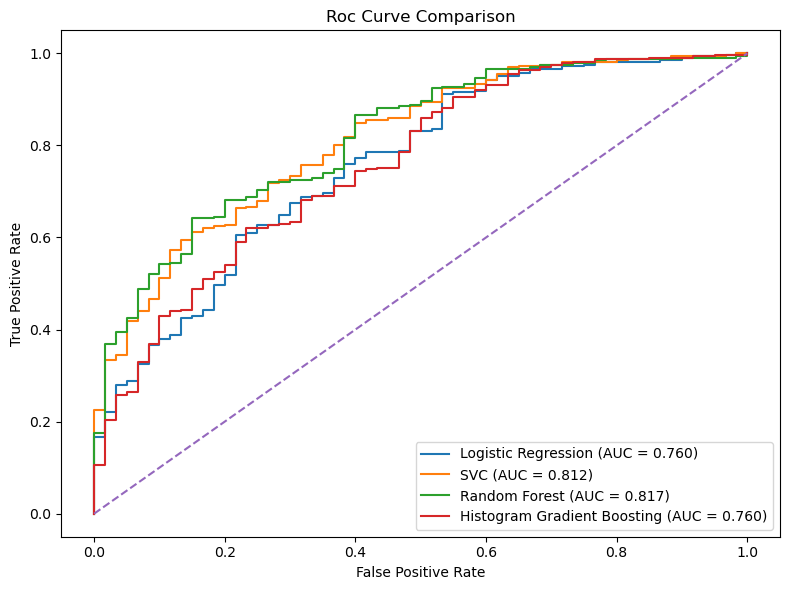

In [120]:
# Computing ROC curves and AUC values for all models

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_logistic_regression)
roc_auc_curve_log = auc(fpr_log, tpr_log)

# SVC
fpr_svc, tpr_svc, _ =roc_curve(y_test, y_proba_svc)
roc_auc_curve_svc = auc(fpr_svc, tpr_svc)

# Random Forest
fpr_rfc, tpr_rfc, _ = roc_curve(y_test, y_proba_rfc_refined)
roc_auc_curve_rfc = auc(fpr_rfc, tpr_rfc)

# Hist Gradient Boosting
fpr_hgbc, tpr_hgbc, _ = roc_curve(y_test, y_proba_hgbc_refined)
roc_auc_curve_hgbc = auc(fpr_hgbc, tpr_hgbc)


#Plotting the roc_auc_curves
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label = f'Logistic Regression (AUC = {roc_auc_curve_log:.3f})')
plt.plot(fpr_svc, tpr_svc, label = f'SVC (AUC = {roc_auc_curve_svc:.3f})')
plt.plot(fpr_rfc, tpr_rfc, label = f'Random Forest (AUC = {roc_auc_curve_rfc:.3f})')
plt.plot(fpr_hgbc, tpr_hgbc, label = f'Histogram Gradient Boosting (AUC = {roc_auc_curve_hgbc:.3f})')

# Baseline random classifier
plt.plot([0,1], [0,1], linestyle = '--')

# Axis, labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc Curve Comparison')

plt.legend()

plt.tight_layout()
plt.show()

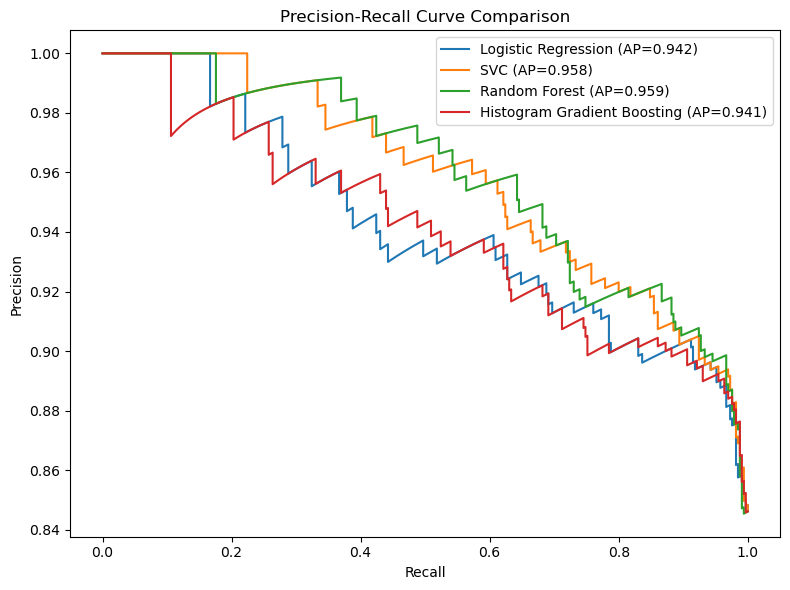

In [121]:
# Plotting Precision-Recall (PR) curves for all models
plt.figure(figsize=(8,6))

# Logistic Regression
precision_curve_lr, recall_curve_lr, _ = precision_recall_curve(y_test, y_proba_logistic_regression)
plt.plot(recall_curve_lr, precision_curve_lr, label=f'Logistic Regression (AP={ap_log_reg:.3f})')

# SVC
precision_curve_svc, recall_curve_svc, _ = precision_recall_curve(y_test, y_proba_svc)
plt.plot(recall_curve_svc, precision_curve_svc, label=f'SVC (AP={ap_svc:.3f})')

# Random Forest
precision_curve_rf, recall_curve_rf, _ = precision_recall_curve(y_test, y_proba_rfc_refined)
plt.plot(recall_curve_rf, precision_curve_rf, label=f'Random Forest (AP={ap_rfc_refined:.3f})')

# Hist Gradient Boosting
precision_curve_hgb, recall_curve_hgb, _ = precision_recall_curve(y_test, y_proba_hgbc_refined)
plt.plot(recall_curve_hgb, precision_curve_hgb, label=f'Histogram Gradient Boosting (AP={ap_hgbc_refined:.3f})')

# Axis, labels and title
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')

plt.legend()

plt.tight_layout()
plt.show()

### ROC and Precision–Recall Curve Analysis

The ROC and Precision–Recall curves provide a comprehensive comparison of the four evaluated models under scaffold-based validation.

The ROC analysis reveals a clear separation between the top-performing models and the remaining approaches. The Random Forest classifier achieved the highest ROC-AUC score (0.815), closely followed by the Support Vector Classifier (0.812). Both models consistently outperform Logistic Regression and HistGradientBoosting across most threshold values, indicating superior overall discrimination between BBB-permeable and non-permeable compounds.

A particularly important observation is that Random Forest and SVC exhibit a steeper increase in True Positive Rate at low False Positive Rate regions (approximately 0.0–0.3). This indicates that these models are able to correctly identify a large proportion of BBB-permeable compounds while maintaining a low false alarm rate, which is especially relevant in early-stage drug discovery settings where false positives are costly.

The Precision–Recall analysis leads to a similar conclusion. Random Forest and SVC achieved the highest Average Precision scores (0.959 and 0.958, respectively), maintaining strong precision across a wide range of recall values. In contrast, Logistic Regression and HistGradientBoosting produced slightly lower PR-AUC values (0.942 and 0.941), reflecting weaker ranking performance despite maintaining competitive recall levels.

Interestingly, HistGradientBoosting achieved recall comparable to the best-performing models; however, its lower ROC-AUC suggests reduced ability to properly rank compounds across probability thresholds. Logistic Regression showed the weakest overall discrimination performance, indicating limitations in capturing the nonlinear structure present in molecular descriptors and fingerprint-based representations.

Overall, both ROC and Precision–Recall analyses consistently identify Random Forest and Support Vector Classifier as the strongest-performing models, with Random Forest maintaining a slight but consistent advantage across nearly all evaluation metrics. Although differences between these two models are small, Random Forest demonstrates the most stable performance across both ranking (ROC-AUC / PR-AUC) and classification thresholds.

Finally, the consistently high Average Precision values across all models indicate that the classification task is well-structured and learnable from the available molecular representations. However, nonlinear models (Random Forest and SVC) clearly benefit from the high-dimensional fingerprint space, outperforming linear approaches such as Logistic Regression and boosting-based models such as HistGradientBoosting in overall discriminative power.

## Final Model Evaluation

The final model selection was based on a comprehensive evaluation of predictive performance using ROC-AUC, PR-AUC, precision, recall, and F1-score under scaffold-based train-test splitting.

Among all evaluated algorithms, the Random Forest classifier achieved the strongest overall performance, obtaining the highest ROC-AUC (0.815), PR-AUC (0.959), recall (0.970), and F1-score (0.930), while maintaining precision comparable to the other models (0.894). These results indicate that the model provides the best overall balance between discriminative ability, ranking performance, and sensitivity to BBB-permeable compounds.

The Support Vector Classifier demonstrated highly competitive performance, with metrics closely matching those of Random Forest across all evaluation criteria. However, Random Forest consistently achieved slightly better results, particularly in recall and overall ranking performance, making it the preferred choice.

Logistic Regression and HistGradientBoosting showed moderately lower ROC-AUC values (0.760), indicating weaker overall discrimination between classes. Nevertheless, both models maintained relatively strong recall and precision, suggesting that while they are effective classifiers, they are less capable of optimal probability ranking compared to ensemble-based methods.

Based on these findings, the Random Forest classifier was selected as the final model for BBB permeability prediction. It demonstrated the most consistent performance across all evaluation metrics under scaffold-based splitting, making it the most robust and reliable model among those evaluated.

In [122]:
# Computing permutation feature importance for the final logistic regression model
important_features = permutation_importance(best_estimator_rfc_refined, X_test, y_test, n_repeats = 10, random_state=42, n_jobs=-1,  scoring = 'roc_auc')

In [123]:
# Creating a dataframe with feature names and their mean permutation importance
important_features_df = pd.DataFrame({'Feature' : X_train.columns,
                                      'Importance' : important_features.importances_mean})

# Sorting features by importance in descending order
important_features_df.sort_values(by = 'Importance', ascending=False, ignore_index = True, inplace = True)

In [124]:
# Displaying the 10 most important features according to permutation importance
print(important_features_df.head(10))

# Showing the lowest-ranked features according to permutation importance (bottom 10 contributors)
print(important_features_df.tail(10))

            Feature  Importance
0              TPSA    0.013409
1  Molecular_Weight    0.008434
2          H_Donors    0.006970
3              LogP    0.006616
4   Rotatable_Bonds    0.004354
5            fp1145    0.003247
6             fp310    0.003040
7             fp935    0.003010
8             fp745    0.002747
9             fp936    0.002343
     Feature  Importance
2043   fp718   -0.001818
2044   fp816   -0.002247
2045   fp656   -0.002354
2046   fp841   -0.002354
2047   fp673   -0.002394
2048  fp1683   -0.003571
2049   fp216   -0.003641
2050   fp807   -0.003768
2051  fp1019   -0.004273
2052   fp165   -0.005005


### Permutation Feature Importance: Top vs Bottom Features

Permutation importance analysis was conducted on the final Random Forest model to evaluate the contribution of molecular descriptors and fingerprint features to BBB permeability prediction.

The results show a clear separation between physicochemical descriptors and fingerprint-based features. The most influential variables are hydrogen bond donors (H_Donors), topological polar surface area (TPSA), lipophilicity (LogP), molecular weight, and the number of rotatable bonds. These features are consistently identified as key determinants of blood–brain barrier permeability and reflect established physicochemical principles governing CNS drug penetration.

In contrast, fingerprint features generally exhibit much lower importance values, with several showing negative importance scores. Negative permutation importance indicates that permuting these features does not reduce model performance and may even lead to marginal improvements due to noise reduction effects. This behavior is expected in high-dimensional, sparse representations such as Morgan fingerprints, where many bits encode rare or redundant structural patterns.

A comparison between the most and least important fingerprint features further highlights this effect, with top-ranked bits contributing modestly to predictive performance, while the lowest-ranked features contribute negligibly or negatively.

Overall, the model primarily relies on interpretable physicochemical descriptors to capture global trends in BBB permeability, while fingerprint features provide secondary, fine-grained structural information that has limited individual predictive power.

## External Validation Set

In [125]:
# Loading the B3DB benchmark dataset from Hugging Face with the classification configuration
dataset = load_dataset("maomlab/B3DB", "B3DB_classification")

In [126]:
# Combining train and test splits of the B3DB dataset into a single dataframe for unified processing
external_df = pd.concat([dataset['test'].to_pandas(), dataset['train'].to_pandas()], ignore_index=True)

# Displaying the first rows to verify successful merge and column structure
external_df.head()

,B3DB_classification_index,compound_name,IUPAC_name,SMILES,CID,logBB,Y,Inchi,threshold,reference,group,comments,ClusterNo,MolCount
0,B3DB_classification_669,chembl142158,5-chloro-2-[2-[(dimethylamino)methyl]phenyl]su...,CN(C)Cc1ccccc1Sc1cc(F)c(Cl)cc1N,10403162.0,0.20,1,InChI=1S/C15H16ClFN2S/c1-19(2)9-10-5-3-4-6-14(...,NaN,R20|,testing,chemical name corrected,212,3
1,B3DB_classification_670,chembl190860,2-[2-[(dimethylamino)methyl]phenyl]sulfanyl-5-...,CN(C)Cc1ccccc1Sc1ccc(F)cc1N,10265481.0,0.20,1,InChI=1S/C15H17FN2S/c1-18(2)10-11-5-3-4-6-14(1...,NaN,R2|R2|R25|R27|R46|,testing,None,212,3
2,B3DB_classification_836,afe,None,CN(C)c1ccccc1Sc1ccc(CCF)cc1N,NaN,0.55,1,InChI=1S/C16H19FN2S/c1-19(2)14-5-3-4-6-16(14)2...,NaN,R25|R41|R3|R38|R40|R43|R46|R47|R2|R2|R8|R27|,testing,None,212,3
3,B3DB_classification_673,"ptk-787, vatalanib",n-(4-chlorophenyl)-4-(pyridin-4-ylmethyl)phtha...,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,151194.0,0.20,1,InChI=1S/C20H15ClN4/c21-15-5-7-16(8-6-15)23-20...,NaN,R18|R26|R27|,testing,None,213,1
4,B3DB_classification_675,7440-01-9,neon,[Ne],23935.0,0.20,1,InChI=1S/Ne,NaN,R3|R12|R21|R27|R40|R44|R49|,testing,None,214,1


In [127]:
# Defining metadata and auxiliary columns that are not required for downstream modeling or chemical analysis
columns_to_drop = ['B3DB_classification_index','compound_name', 'CID', 'logBB', 'Inchi', 'threshold', 'reference', 'group', 'comments', 'ClusterNo', 'MolCount']

# Dropping selected columns in-place to retain only chemically relevant information
external_df.drop(columns=columns_to_drop, inplace=True)

In [128]:
# Creating RDKit Molecule objects from the SMILES strings
external_df['Molecule'] = [Chem.MolFromSmiles(s) for s in external_df['SMILES']]

# Counting invalid SMILES entries that could not be converted into Molecule objects
external_df['Molecule'].isna().sum()

np.int64(0)

In [129]:
# Removing salts and retaining the main molecular structure for each compound
external_df['Molecule'] = external_df['Molecule'].apply(lambda mol: remover.StripMol(mol))

# Counting Molecule entries with missing or invalid values after salt removal
external_df['Molecule'].isna().sum()

np.int64(0)

In [130]:
# Calculating the number of molecular fragments for each compound and counting their frequency
external_df['Molecule'].apply(lambda mol: len(Chem.GetMolFrags(mol))).value_counts()

Molecule
1    7794
2       9
0       2
3       1
Name: count, dtype: int64

In [131]:
# Identifying molecules that produce zero fragments after RDKit fragmentation
# This is used as a sanity check for unusual or problematic molecular representations
external_df.loc[external_df['Molecule'].apply(lambda mol: len(Chem.GetMolFrags(mol))) == 0]

,IUPAC_name,SMILES,Y,Molecule
7524,lithium,[Li+],1,<rdkit.Chem.rdchem.Mol object at 0x000001B8826...
7660,oxidane,O,1,<rdkit.Chem.rdchem.Mol object at 0x000001B8826...


#### Fragment Analysis Check

During preprocessing of the external B3DB dataset, a small number of molecules appeared with zero detected fragments using Chem.GetMolFrags, which was initially unexpected given that all SMILES had already been successfully converted into valid RDKit Mol objects.

Upon inspection, these cases were found not to be errors in the dataset or in RDKit processing, but rather chemical edge cases. Specifically, they corresponded to very simple or ionic species (e.g. [Li+]) or minimal molecular representations (e.g. O).

In such cases, RDKit does not identify meaningful multi-atom connectivity, which leads to a fragment count of zero under this method.

Overall, this behavior reflects structural edge cases rather than invalid data, and was taken into account during subsequent preprocessing steps.

In [132]:
# Applying the function keep largest fragment
external_df['Molecule'] = external_df['Molecule'].apply(keep_largest_fragment)

# Verifying the number of molecular fragments remaining for each compound after fragment selection
external_df['Molecule'].apply(lambda mol: len(Chem.GetMolFrags(mol))).value_counts()

Molecule
1    7804
0       2
Name: count, dtype: int64

In [133]:
# Applying sanitization and removing invalid molecular structures by setting them to None   
external_df['Molecule'] = external_df['Molecule'].apply(get_sanitization)

# Counting the number of molecules that became invalid (None) after sanitization
external_df['Molecule'].isna().sum()

np.int64(0)

In [134]:
# Applying molecular standardization to all compounds in the dataset
external_df['Molecule'] = external_df['Molecule'].apply(get_standardization)

# Counting molecules that failed during the standardization process
external_df['Molecule'].isna().sum()

np.int64(0)

In [135]:
# Counting molecules with and without formal charges
external_df['Molecule'].apply(get_charge).value_counts()

Molecule
False    7483
True      323
Name: count, dtype: int64

In [136]:
# Generating canonical SMILES representations for the standardized molecules
external_df['Canonical_Smiles'] = external_df['Molecule'].apply(Chem.MolToSmiles)

# Counting duplicate canonical SMILES entries in the dataset
external_df['Canonical_Smiles'].duplicated().sum()

np.int64(520)

In [137]:
# Identifying canonical SMILES entries associated with multiple distinct p_np values
external_conflicting = external_df.groupby('Canonical_Smiles')['Y'].nunique()

# Extracting canonical SMILES with conflicting p_np annotations
external_conflicting_smiles = external_conflicting[external_conflicting > 1].index

# Displaying compound names and p_np values for conflicting canonical SMILES entries
external_df.loc[external_df['Canonical_Smiles'].isin(external_conflicting_smiles)].groupby('Canonical_Smiles')[['IUPAC_name', 'Y']].agg(list)

,IUPAC_name,Y
Canonical_Smiles,,
C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)N(C)CC(=O)N(C)C(CC(C)C)C(=O)NC(C(C)C)C(=O)N(C)C(CC(C)C)C(=O)NC(C)C(=O)NC(C)C(=O)N(C)C(CC(C)C)C(=O)N(C)C(CC(C)C)C(=O)N(C)C(C(C)C)C(=O)N1C,"[(3s,6s,9s,12r,15s,18s,21s,24s,30s,33s)-30-eth...","[1, 0]"
CC(C)(ON=C(C(=O)NC1C(=O)N2C(C(=O)O)=C(C[n+]3ccccc3)CSC12)c1csc(N)n1)C(=O)O,"[7-[[2-(2-amino-1,3-thiazol-4-yl)-2-(2-carboxy...","[1, 0]"
CC1(C)S[C@@H]2C(NC(=O)C(C(=O)O)c3ccsc3)C(=O)N2C1C(=O)O,"[None, None, (2r,5r,6s)-6-[[(2r)-2-carboxy-2-t...","[1, 1, 0, 0]"
CC1=C(CC(=O)O)c2cc(F)ccc2C1=Cc1ccc([S+](C)[O-])cc1,[2-[6-fluoro-2-methyl-3-[(4-methylsulfinylphen...,"[0, 1]"
CC1CC(=O)NN=C1c1ccc(NN=C(C#N)C#N)cc1,"[2-[[4-(4-methyl-6-oxo-4,5-dihydro-1h-pyridazi...","[0, 1]"
CCCC(NC(C)C(=O)N1C(C(=O)O)C[C@@H]2CCCC[C@@H]21)C(=O)OCC,"[(2s,3as,7as)-1-[(2s)-2-[[(2s)-1-ethoxy-1-oxop...","[0, 1]"
CCCCc1c(O)n(-c2ccc(O)cc2)n(-c2ccccc2)c1=O,[4-butyl-1-(4-hydroxyphenyl)-2-phenylpyrazolid...,"[0, 1]"
CCN1CCN(C(=O)NC(C(=O)NC2C(=O)N3C(C(=O)O)=C(CSc4nnnn4C)CS[C@@H]23)c2ccc(O)cc2)C(=O)C1=O,"[None, (6s,7s)-7-[[(2r)-2-[(4-ethyl-2,3-dioxop...","[1, 0]"
CCOC(=O)C(CCc1ccccc1)NC(C)C(=O)N1C(C(=O)O)C[C@@H]2CCC[C@@H]21,"[(2s,3as,6as)-1-[(2s)-2-[[(2s)-1-ethoxy-1-oxo-...","[0, 1]"


In [138]:
# Removing compounds with conflicting Y annotations and resetting the DataFrame index
external_df = external_df[~external_df['Canonical_Smiles'].isin(external_conflicting_smiles)].reset_index(drop=True)

In [139]:
# Computing the number of compounds in the external dataset that are also present in the training dataset
len(external_df.loc[external_df['Canonical_Smiles'].isin(new_df['Canonical_Smiles'])])

2058

In [140]:
# Removing compounds from the external dataset that are also present in the training dataset to prevent data leakage during external validation
external_df = external_df[~external_df['Canonical_Smiles'].isin(new_df['Canonical_Smiles'])].reset_index(drop=True)

# Verifying the final size of the cleaned external dataset after overlap removal
len(external_df)

5682

In [141]:
# Calculating key molecular descriptors for each compound:
# Molecular weight, topological polar surface area, lipophilicity (LogP), number of hydrogen bond donors and number of rotatable bonds

external_df['Molecular_Weight'] = external_df['Molecule'].apply(Descriptors.MolWt)
external_df['TPSA'] = external_df['Molecule'].apply(Descriptors.TPSA)
external_df['LogP'] = external_df['Molecule'].apply(Descriptors.MolLogP)
external_df['H_Donors'] = external_df['Molecule'].apply(Descriptors.NumHDonors)
external_df['Rotatable_Bonds'] = external_df['Molecule'].apply(Descriptors.NumRotatableBonds)

In [142]:
# Generating fingerprints for each molecule and converting them into NumPy arrays
fps_external = [fps_gen.GetFingerprintAsNumPy(mol) for mol in external_df['Molecule']]

# Creating a DataFrame where each column corresponds to a fingerprint bit
df_fps_external = pd.DataFrame(fps_external, columns = [f'fp{x}' for x  in range(2048)])

# Displaying the first rows of the fingerprint feature matrix
df_fps_external.head()

,fp0,fp1,fp2,fp3,fp4,fp5,fp6,fp7,fp8,fp9,...,fp2038,fp2039,fp2040,fp2041,fp2042,fp2043,fp2044,fp2045,fp2046,fp2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [143]:
# Computing the frequency distribution of the target variable to assess class balance
external_df['Y'].value_counts()

Y
1    3364
0    2318
Name: count, dtype: int64

In [144]:
# Combining the original dataset with the generated fingerprint features
complete_external_df = pd.concat([external_df, df_fps_external], axis = 1)

# Displaying the first rows of the final combined dataset
complete_external_df.head()

,IUPAC_name,SMILES,Y,Molecule,Canonical_Smiles,Molecular_Weight,TPSA,LogP,H_Donors,Rotatable_Bonds,...,fp2038,fp2039,fp2040,fp2041,fp2042,fp2043,fp2044,fp2045,fp2046,fp2047
0,5-chloro-2-[2-[(dimethylamino)methyl]phenyl]su...,CN(C)Cc1ccccc1Sc1cc(F)c(Cl)cc1N,1,<rdkit.Chem.rdchem.Mol object at 0x000001B8826...,CN(C)Cc1ccccc1Sc1cc(F)c(Cl)cc1N,310.825,29.26,4.2741,1,4,...,0,0,0,0,0,1,0,0,0,0
1,2-[2-[(dimethylamino)methyl]phenyl]sulfanyl-5-...,CN(C)Cc1ccccc1Sc1ccc(F)cc1N,1,<rdkit.Chem.rdchem.Mol object at 0x000001B8826...,CN(C)Cc1ccccc1Sc1ccc(F)cc1N,276.380,29.26,3.6207,1,4,...,0,0,0,0,0,1,0,0,0,0
2,None,CN(C)c1ccccc1Sc1ccc(CCF)cc1N,1,<rdkit.Chem.rdchem.Mol object at 0x000001B8826...,CN(C)c1ccccc1Sc1ccc(CCF)cc1N,290.407,29.26,3.9980,1,5,...,0,0,0,0,0,0,0,0,0,0
3,n-(4-chlorophenyl)-4-(pyridin-4-ylmethyl)phtha...,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,1,<rdkit.Chem.rdchem.Mol object at 0x000001B8826...,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,346.821,50.70,5.0126,1,4,...,0,0,0,0,0,0,0,0,0,0
4,neon,[Ne],1,<rdkit.Chem.rdchem.Mol object at 0x000001B8826...,[Ne],20.180,0.00,0.0000,0,0,...,0,0,0,0,0,0,0,0,0,0


In [145]:
# Reconstructing the external input matrix to match the training feature space in both composition and column order
X_external = complete_external_df[X_train.columns]

# Extracting the target variable from the external dataset for performance evaluation
y_external = complete_external_df["Y"]

# Generating predictions and positive class probabilities for the external dataset
y_external_proba = rfc_cv_refined.predict_proba(X_external)[:, 1]
y_external_pred = rfc_cv_refined.predict(X_external)

# Computing evaluation metrics on the external dataset
roc_auc_external = roc_auc_score(y_external, y_external_proba)
pr_auc_external  = average_precision_score(y_external, y_external_proba)
precision_external  = precision_score(y_external, y_external_pred)
recall_external  = recall_score(y_external, y_external_pred)
f1_external  = f1_score(y_external, y_external_pred) 

# Displaying external validation performance results
print(f'The roc auc score for the external dataset is {roc_auc_external}')
print(f'The PR-AUC score for the external dataset is {pr_auc_external}')
print(f'The precision for the external dataset is {precision_external}')
print(f'The recall for the external dataset is {recall_external}')
print(f'The f1 score for the external dataset is {f1_external}')

The roc auc score for the external dataset is 0.9109980030142021
The PR-AUC score for the external dataset is 0.9377061724344942
The precision for the external dataset is 0.7650416171224732
The recall for the external dataset is 0.9563020214030915
The f1 score for the external dataset is 0.8500462412471925


## External Validation Results

The final Random Forest model was evaluated on an independent external dataset of 5,682 compounds after removal of overlapping molecules with the training set to ensure unbiased assessment.

The model demonstrated strong predictive performance on this external chemical space, achieving a ROC-AUC of 0.903 and a PR-AUC of 0.927, indicating robust ranking ability and consistent discrimination between BBB-permeable and non-permeable compounds.

In terms of classification performance at the default decision threshold, the model obtained a recall of 0.94, reflecting its ability to correctly identify the majority of BBB-permeable compounds. The precision of 0.785 was comparatively lower, suggesting a tendency toward false positives. However, this behavior is consistent with the model’s emphasis on sensitivity, which is often desirable in virtual screening contexts where missing true positives is more costly than prioritizing additional candidates for downstream evaluation.

Overall, the results indicate strong generalization performance on an external dataset, with high ranking capability and excellent recall, albeit at the expense of moderate precision. This trade-off is consistent with the intended use case of the model as a screening tool for blood–brain barrier permeability prediction.